In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import os
import cv2
import glob
import numpy as np
from sklearn.metrics import confusion_matrix
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
color2class = {
    (0, 0, 0): 0,
    (0, 0, 255): 1,
    (0, 255, 0): 2,
    (0, 255, 255): 3,
    (255, 0, 0): 4,
    (255, 0, 255): 5,
    (255, 255, 0): 6,
    (255, 255, 255): 7
}

In [3]:
def convert_mask_to_class(mask):
    h, w, _ = mask.shape
    class_mask = np.zeros((h, w), dtype=np.int64)
    for rgb, cls in color2class.items():
        class_mask[np.all(mask == rgb, axis=-1)] = cls
    return class_mask

In [4]:
class SUIMDataset(Dataset):
    def __init__(self, root, split, transform=None):
        self.image_dir = os.path.join(root, f"{split}/images")
        self.mask_dir = os.path.join(root, f"{split}/masks")
        self.transform = transform
        self.image_paths = sorted(glob.glob(os.path.join(self.image_dir, "*.jpg")))
        self.mask_paths = sorted(glob.glob(os.path.join(self.mask_dir, "*.bmp")))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("RGB")
        mask = mask.resize((256, 256), resample=Image.NEAREST)
        mask = convert_mask_to_class(np.array(mask))

        if self.transform:
            img = self.transform(img)

        mask = torch.tensor(mask, dtype=torch.long)
        return img, mask

In [5]:
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [6]:
train_dataset = SUIMDataset(root="/content/drive/MyDrive/SUIM", split="train_val", transform=transform)
test_dataset = SUIMDataset(root="/content/drive/MyDrive/SUIM", split="TEST", transform=transform)

In [7]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

In [8]:
class SimpleUNet(nn.Module):
    def __init__(self, num_classes=8):
        super(SimpleUNet, self).__init__()
        self.enc1 = nn.Conv2d(3, 64, 3, padding=1)
        self.enc2 = nn.Conv2d(64, 128, 3, padding=1)
        self.enc3 = nn.Conv2d(128, 256, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.dec3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.out = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        x1 = F.relu(self.enc1(x))
        x2 = F.relu(self.enc2(self.pool(x1)))
        x3 = F.relu(self.enc3(self.pool(x2)))

        d3 = F.relu(self.dec3(x3))
        d2 = F.relu(self.dec2(d3))
        out = self.out(d2)
        return out

In [9]:
def compute_iou(pred, target, num_classes=8):
    pred = pred.flatten()
    target = target.flatten()
    cm = confusion_matrix(target, pred, labels=list(range(num_classes)))
    intersection = np.diag(cm)
    union = cm.sum(axis=1) + cm.sum(axis=0) - intersection
    iou = intersection / np.maximum(union, 1)
    return np.nanmean(iou)

In [10]:
def compute_dice(pred, target, num_classes=8):
    pred = pred.flatten()
    target = target.flatten()
    cm = confusion_matrix(target, pred, labels=list(range(num_classes)))
    intersection = np.diag(cm)
    dice = (2 * intersection) / np.maximum(cm.sum(axis=1) + cm.sum(axis=0), 1)
    return np.nanmean(dice)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleUNet(num_classes=8).to(device)
print(device)

cpu


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
for epoch in range(15):
    model.train()
    total_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 1.5280
Epoch 2, Loss: 1.3472
Epoch 3, Loss: 1.3049
Epoch 4, Loss: 1.2715
Epoch 5, Loss: 1.2483
Epoch 6, Loss: 1.2327
Epoch 7, Loss: 1.2241
Epoch 8, Loss: 1.2193
Epoch 9, Loss: 1.2115
Epoch 10, Loss: 1.2130
Epoch 11, Loss: 1.2084
Epoch 12, Loss: 1.1968
Epoch 13, Loss: 1.1988
Epoch 14, Loss: 1.1969
Epoch 15, Loss: 1.1881


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/models-results/checkpoint-without-energy.pth")

In [ ]:
model.eval()
ious, dices = [], []
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        masks = masks.cpu().numpy()
        for p, m in zip(preds, masks):
            ious.append(compute_iou(p, m))
            dices.append(compute_dice(p, m))

In [ ]:
print(f"Mean IoU: {np.mean(ious):.3f}")
print(f"Mean Dice: {np.mean(dices):.3f}")

Mean IoU: 0.120
Mean Dice: 0.145


In [ ]:
print(f"Max IoU: {np.max(ious):.3f}")
print(f"Max Dice: {np.max(dices):.3f}")

Max IoU: 0.244
Max Dice: 0.290


In [ ]:
def mask_to_rgb(mask, class_colors):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, color in class_colors.items():
        rgb[mask == cls] = color
    return rgb

In [ ]:
class_colors = {
    0: (0, 0, 0),
    1: (0, 0, 255),
    2: (0, 255, 0),
    3: (0, 255, 255),
    4: (255, 0, 0),
    5: (255, 0, 255),
    6: (255, 255, 0),
    7: (255, 255, 255)
}


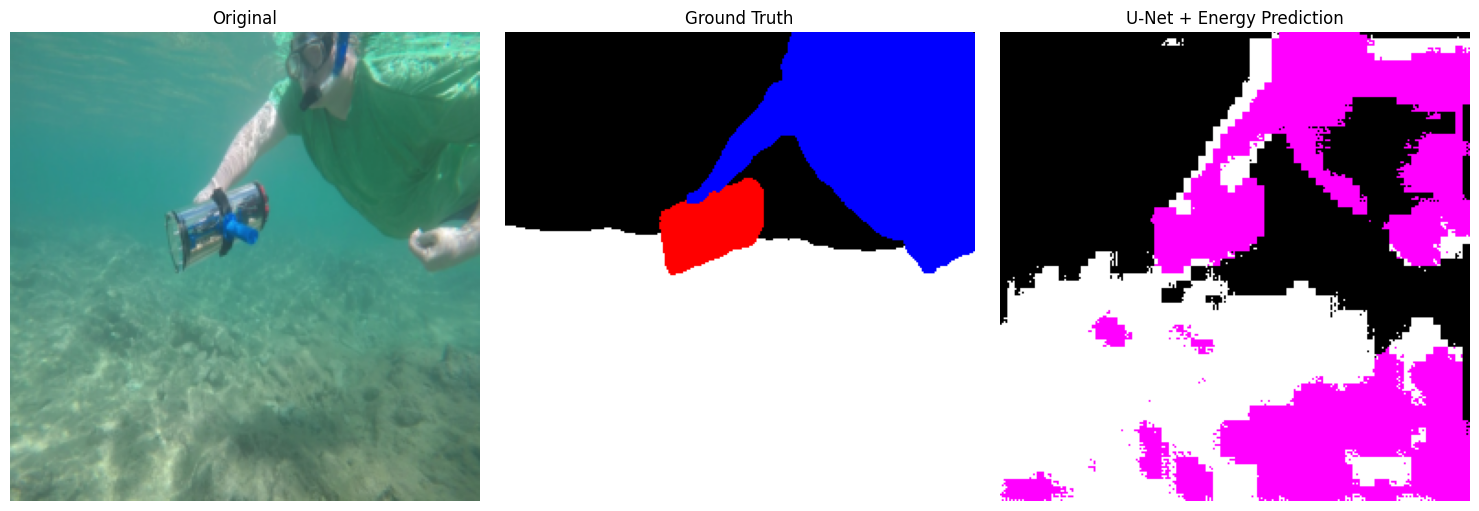

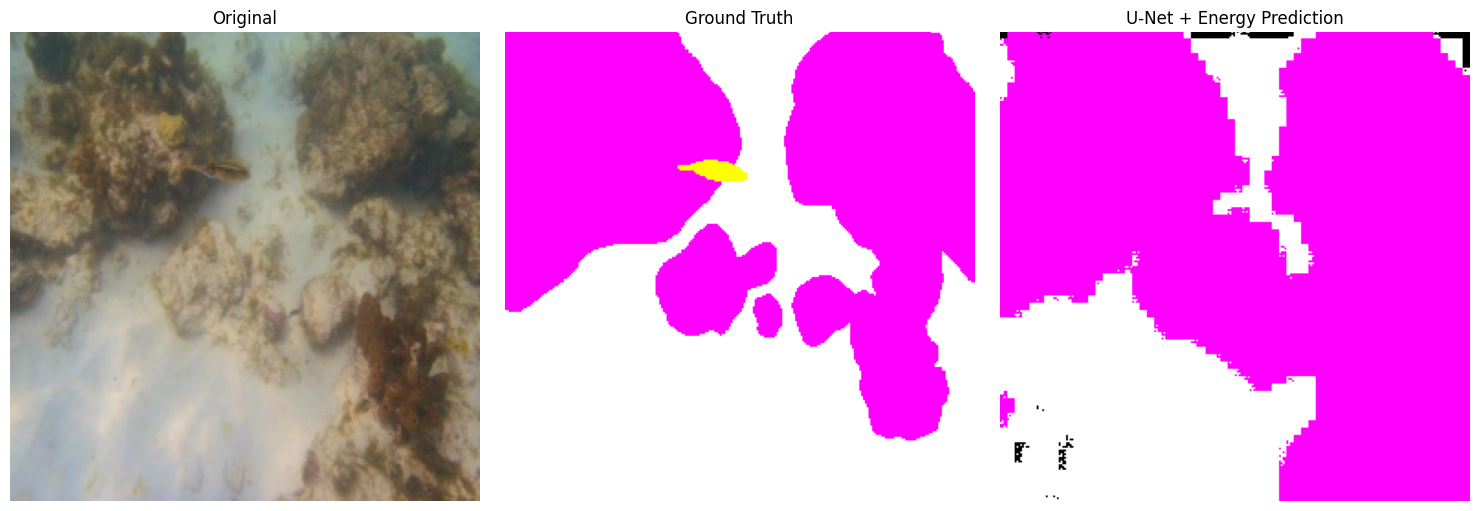

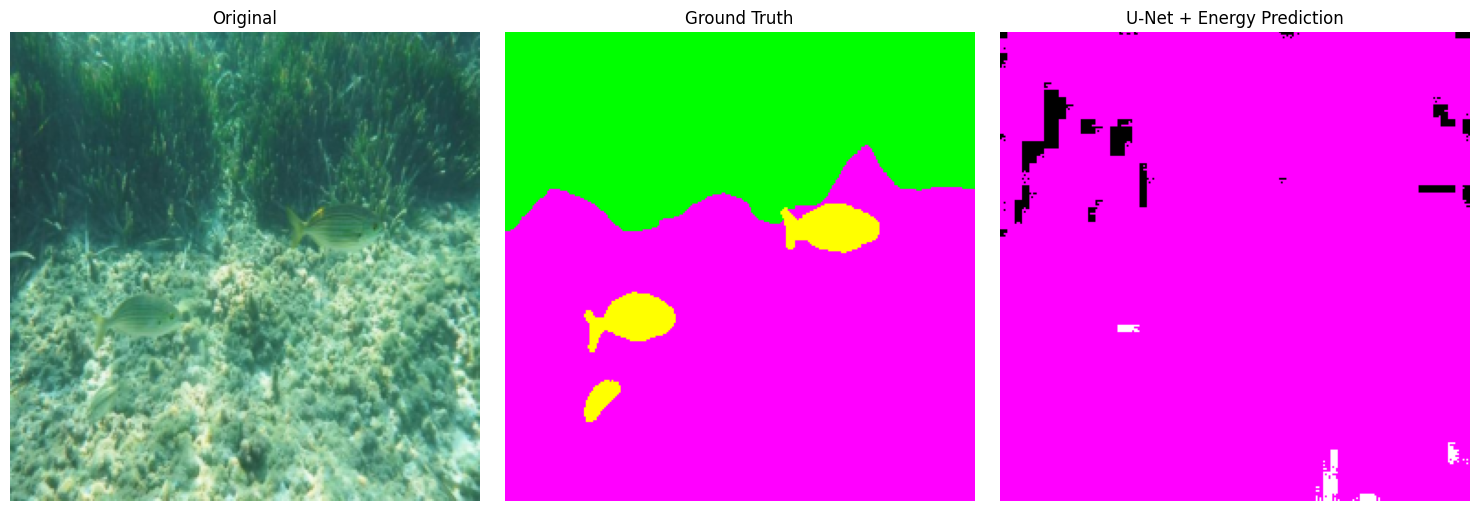

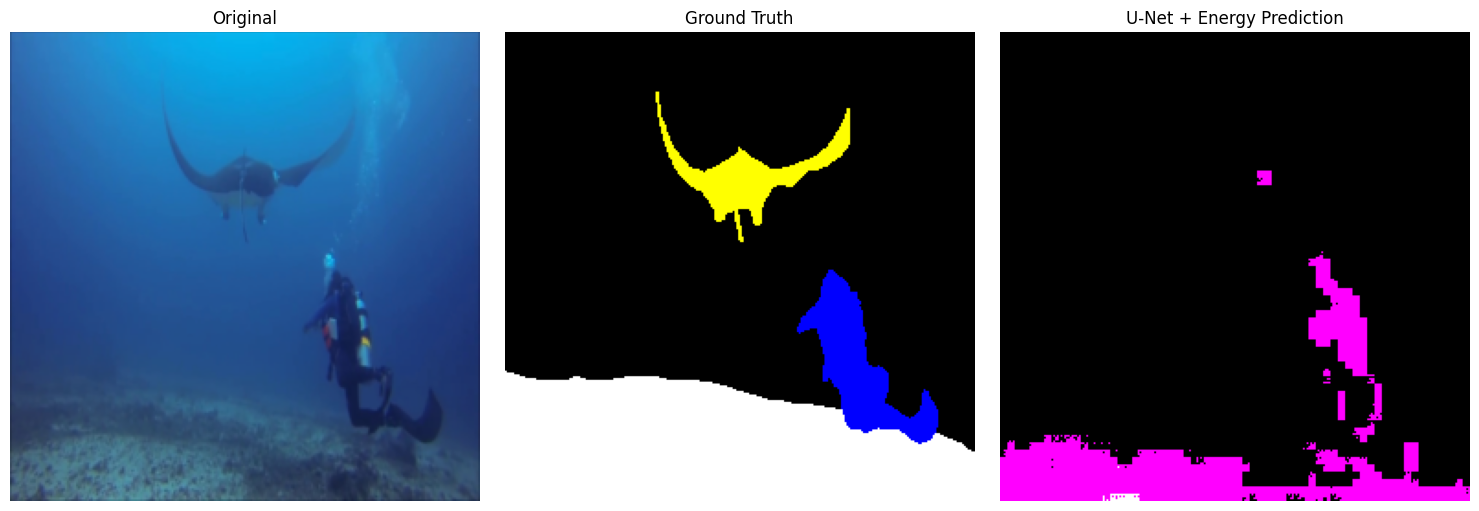

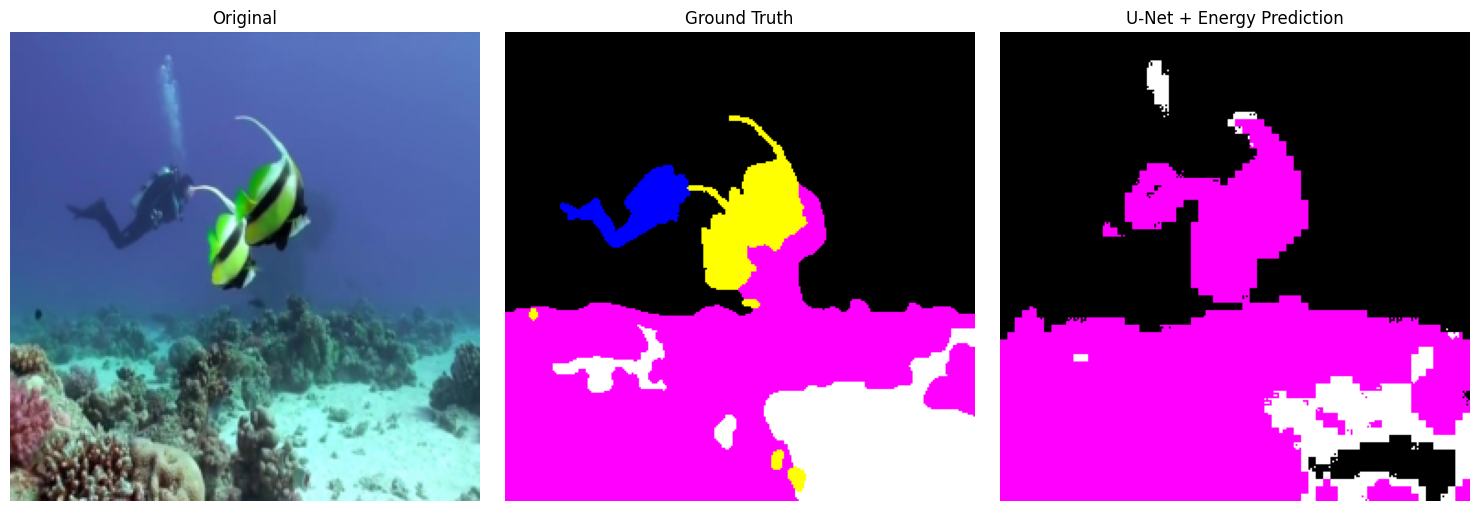

In [ ]:
model.eval()
with torch.no_grad():
    for idx in range(5):
        img, mask = test_dataset[idx]
        img = img.unsqueeze(0).to(device)
        mask = mask.to(device)

        preds = model(img)
        pred_classes = preds.squeeze(0).argmax(dim=0).cpu().numpy()
        gt_classes = mask.cpu().numpy()

        gt_rgb = mask_to_rgb(gt_classes, class_colors)
        pred_rgb = mask_to_rgb(pred_classes, class_colors)

        plt.figure(figsize=(15,5))

        # Original
        plt.subplot(1,3,1)
        plt.imshow(np.transpose(img[0], (1, 2, 0)) * 0.5 + 0.5)
        plt.title("Original"); plt.axis("off")

        # Ground Truth
        plt.subplot(1,3,2)
        plt.imshow(gt_rgb)
        plt.title("Ground Truth"); plt.axis("off")

        # CNN Prediction
        plt.subplot(1,3,3)
        plt.imshow(pred_rgb)
        plt.title("U-Net + Energy Prediction"); plt.axis("off") # misprint, u-net witOUT energy 

        plt.tight_layout()
        plt.show()

In [13]:
model.load_state_dict(torch.load("/content/drive/MyDrive/models-results/checkpoint-without-energy.pth"))

<All keys matched successfully>

In [14]:
for epoch in range(15, 30):
    model.train()
    total_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 16, Loss: 1.1869
Epoch 17, Loss: 1.1868
Epoch 18, Loss: 1.1891
Epoch 19, Loss: 1.1769
Epoch 20, Loss: 1.1743
Epoch 21, Loss: 1.1725
Epoch 22, Loss: 1.1689
Epoch 23, Loss: 1.1622
Epoch 24, Loss: 1.1605
Epoch 25, Loss: 1.1548
Epoch 26, Loss: 1.1542
Epoch 27, Loss: 1.1463
Epoch 28, Loss: 1.1412
Epoch 29, Loss: 1.1392
Epoch 30, Loss: 1.1350


In [15]:
torch.save(model.state_dict(), "/content/drive/MyDrive/models-results/checkpoint-without-energy-2.pth")

In [16]:
model.eval()
ious, dices = [], []
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        masks = masks.cpu().numpy()
        for p, m in zip(preds, masks):
            ious.append(compute_iou(p, m))
            dices.append(compute_dice(p, m))

In [22]:
print(f"Mean IoU: {np.mean(ious):.3f}")
print(f"Mean Dice: {np.mean(dices):.3f}")

Mean IoU: 0.132
Mean Dice: 0.161


In [23]:
print(f"Max IoU: {np.max(ious):.3f}")
print(f"Max Dice: {np.max(dices):.3f}")

Max IoU: 0.282
Max Dice: 0.324


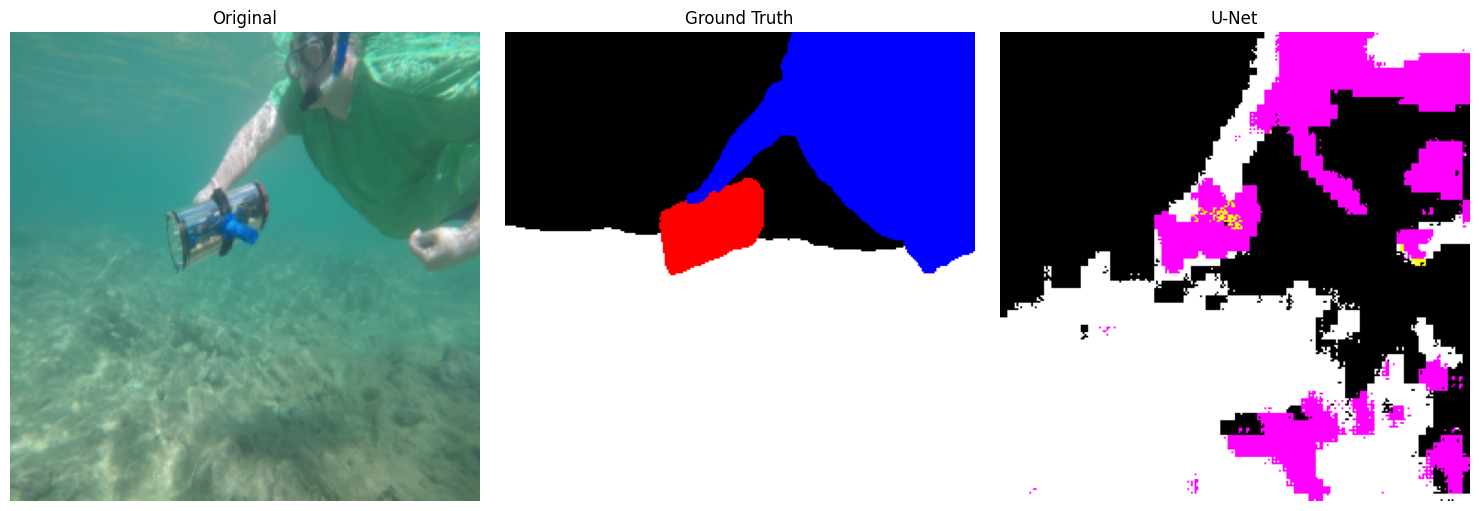

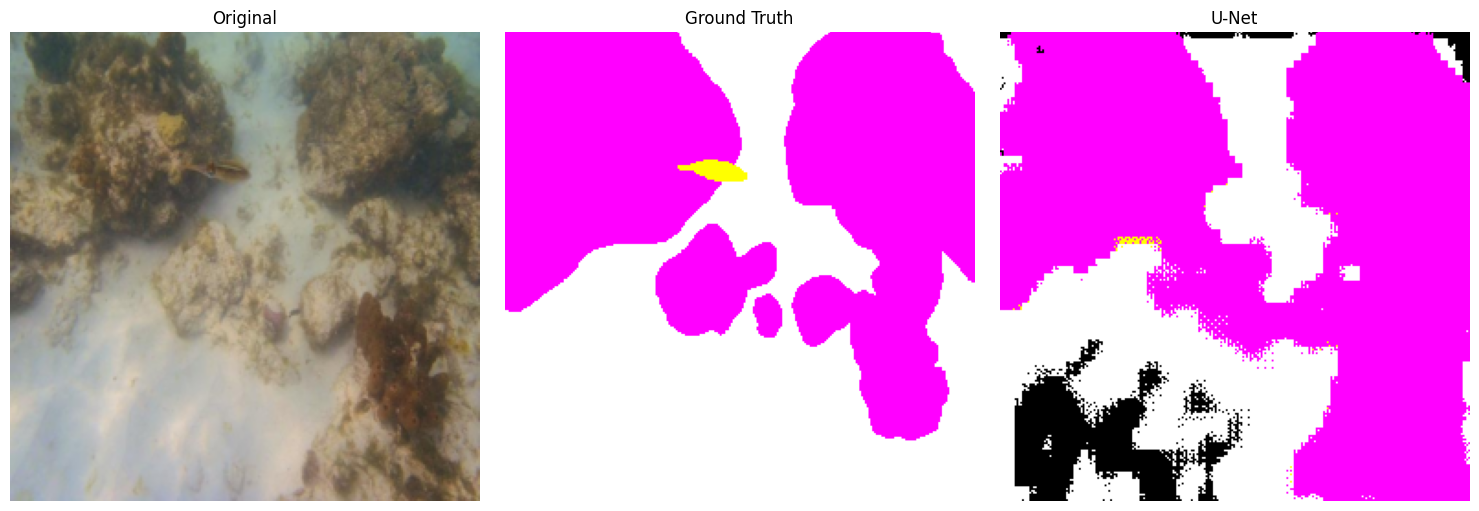

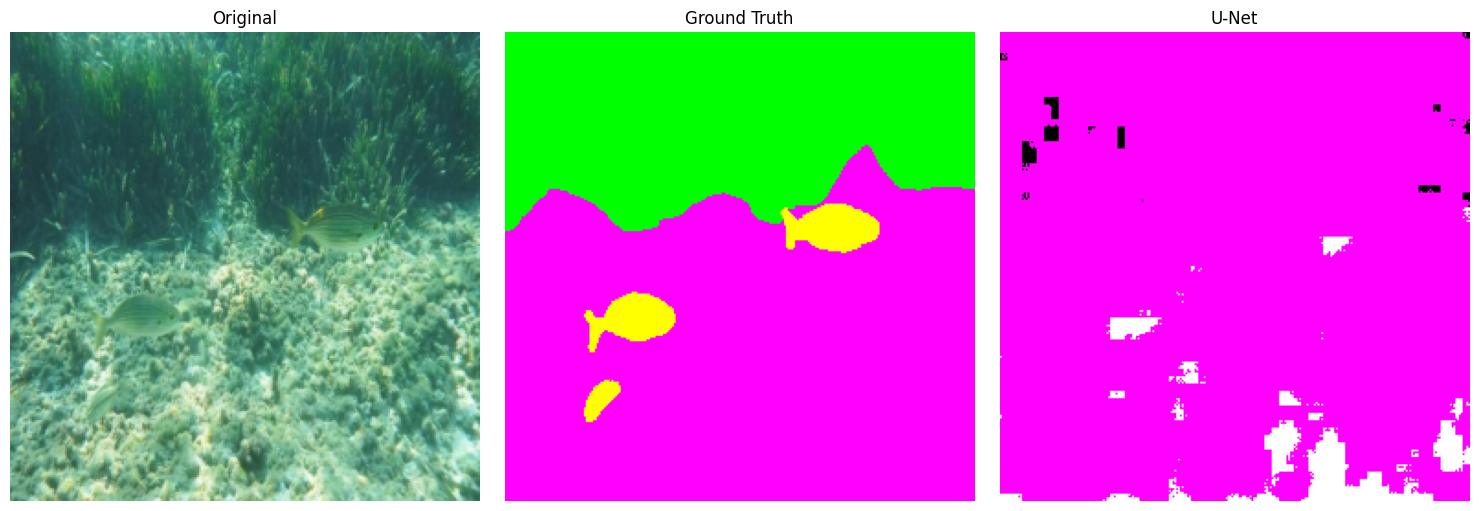

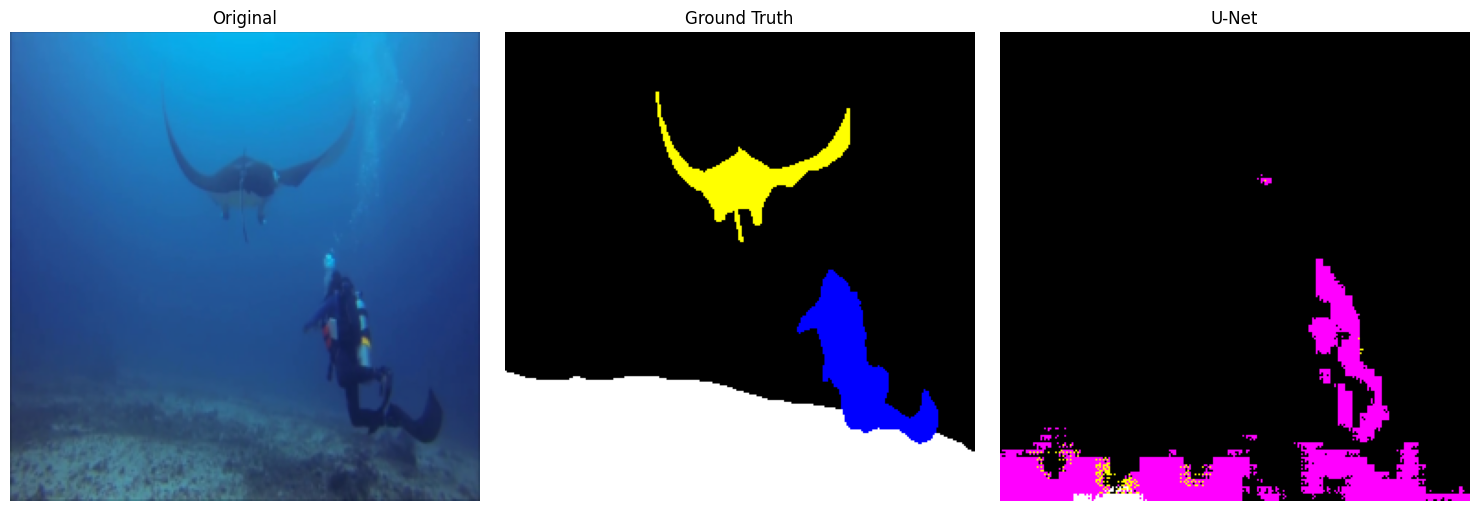

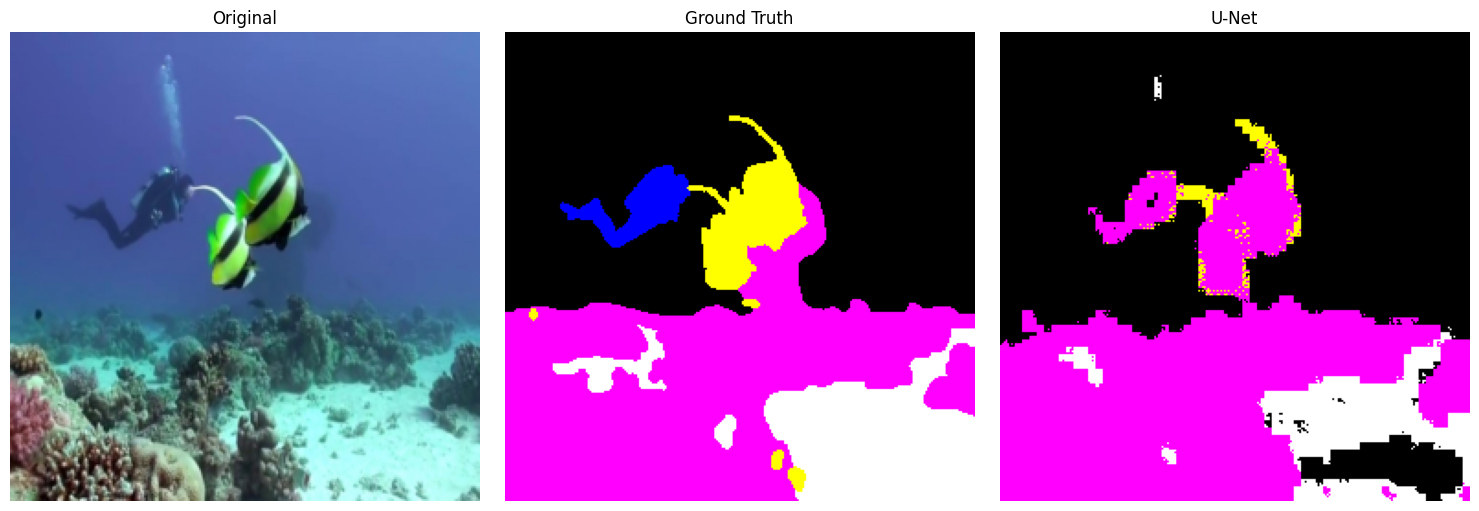

In [ ]:
model.eval()
with torch.no_grad():
    for idx in range(5):
        img, mask = test_dataset[idx]
        img = img.unsqueeze(0).to(device)
        mask = mask.to(device)

        preds = model(img)
        pred_classes = preds.squeeze(0).argmax(dim=0).cpu().numpy()
        gt_classes = mask.cpu().numpy()

        gt_rgb = mask_to_rgb(gt_classes, class_colors)
        pred_rgb = mask_to_rgb(pred_classes, class_colors)

        plt.figure(figsize=(15,5))

        # Original
        plt.subplot(1,3,1)
        plt.imshow(np.transpose(img[0], (1, 2, 0)) * 0.5 + 0.5)
        plt.title("Original"); plt.axis("off")

        # Ground Truth
        plt.subplot(1,3,2)
        plt.imshow(gt_rgb)
        plt.title("Ground Truth"); plt.axis("off")

        # CNN Prediction
        plt.subplot(1,3,3)
        plt.imshow(pred_rgb)
        plt.title("U-Net"); plt.axis("off")

        plt.tight_layout()
        plt.show()